<a href="https://colab.research.google.com/github/Nazarchona/Tutorial/blob/main/%D0%9B%D0%912_2_%D0%93%D1%83%D1%94%D0%B2_%D0%9D%D0%B0%D0%B7%D0%B0%D1%80_%D0%A4%D0%86%D0%A2_4_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завдання 1
Був присутній на парі

Вивести перші 5 рядків датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

df = pd.read_csv('titanic.csv')

print("Датасет успішно завантажено!")

Saving titanic.csv to titanic (1).csv
Датасет успішно завантажено!


1. Вивести перші 5 рядків датасета

In [2]:
print("Перші 5 рядків датасета Titanic:")
display(df.head())

Перші 5 рядків датасета Titanic:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2. Визначити розмір датасета

In [3]:
print("Розмір датасета:", df.shape)
print("Кількість рядків:", df.shape[0])
print("Кількість стовпців:", df.shape[1])

Розмір датасета: (891, 12)
Кількість рядків: 891
Кількість стовпців: 12


3. Визначити оптимальну кількість стовпців

In [4]:
df = df.drop(columns=["PassengerId"])

print("Розмір після видалення зайвого стовпця:", df.shape)
print("\nСтовпці:")
print(df.columns.tolist())

Розмір після видалення зайвого стовпця: (891, 11)

Стовпці:
['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


4. Замінити пропущені значення та перевірити їх

In [5]:
# Видаляємо Cabin через велику кількість пропущених значень
df = df.drop(columns=["Cabin"])

# Перевірка пропущених значень
print("Кількість пропущених значень:")
print(df.isnull().sum())

Кількість пропущених значень:
Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64


In [6]:
# Числові стовпці
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())

In [7]:
# Категоріальні стовпці
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Кількість пропущених значень після заповнення:")
print(df.isnull().sum())

Кількість пропущених значень після заповнення:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


5. Ще раз вивести датасет

In [8]:
print("Датасет після обробки:")
display(df)

Датасет після обробки:


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


6. Перевірити наявність дублікатів

In [9]:
duplicates = df.duplicated().sum()

print("Кількість дублікатів:", duplicates)

Кількість дублікатів: 0


In [10]:
df = df.drop_duplicates()

print("Розмір датасету після видалення дублікатів:", df.shape)

Розмір датасету після видалення дублікатів: (891, 10)


7. Вивести описову статистику датасету

In [11]:
print("Описова статистика:")
display(df.describe())

Описова статистика:


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


8. Обчислити відхилення показників для різних груп пасажирів

Оскільки в Titanic немає IMF / World Bank, тут аналогічне завдання виконуємо для середньої вартості квитка за класами пасажирів.

In [12]:
average_fare = df.groupby("Pclass")["Fare"].mean()

overall_average = df["Fare"].mean()

fare_difference = average_fare - overall_average

result = pd.DataFrame({
    "Середня вартість квитка": average_fare,
    "Відхилення від загальної середньої": fare_difference
})

print("Відхилення середньої вартості квитка за класами:")
display(result.sort_values(
    "Відхилення від загальної середньої",
    ascending=False
))

print("\nКлас із найбільшим позитивним відхиленням:")
print(fare_difference.idxmax())

print("\nКлас із найбільшим негативним відхиленням:")
print(fare_difference.idxmin())

Відхилення середньої вартості квитка за класами:


,Середня вартість квитка,Відхилення від загальної середньої
Pclass,,
1,84.154687,51.950480
2,20.662183,-11.542025
3,13.675550,-18.528658



Клас із найбільшим позитивним відхиленням:
1

Клас із найбільшим негативним відхиленням:
3


9. Обчислити кореляцію між числовими показниками

In [13]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("Кореляційна матриця:")
display(correlation_matrix)

Кореляційна матриця:


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


In [14]:
# Отримуємо верхню частину кореляційної матриці
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=abs,
    ascending=False
)

print("Найсильніші кореляції:")
display(corr_pairs.head(10))

Найсильніші кореляції:


,,0
Pclass,Fare,-0.549500
SibSp,Parch,0.414838
Survived,Pclass,-0.338481
Pclass,Age,-0.331339
Survived,Fare,0.257307
Age,SibSp,-0.232625
Parch,Fare,0.216225
Age,Parch,-0.179191
SibSp,Fare,0.159651
Age,Fare,0.091566


In [15]:
survival_correlation = correlation_matrix["Survived"].drop(
    "Survived"
).sort_values(
    key=abs,
    ascending=False
)

print("Кореляція показників із виживанням:")
display(survival_correlation)

Кореляція показників із виживанням:


,Survived
Pclass,-0.338481
Fare,0.257307
Parch,0.081629
Age,-0.069809
SibSp,-0.035322


10. Обчислити середнє значення за стовпцями

In [16]:
mean_values = df.select_dtypes(include=np.number).mean()

print("Середні значення за числовими стовпцями:")
display(mean_values.round(2))

Середні значення за числовими стовпцями:


,0
Survived,0.38
Pclass,2.31
Age,29.70
SibSp,0.52
Parch,0.38
Fare,32.20


11. Обчислити стандартне відхилення показників

In [17]:
std_values = df.select_dtypes(include=np.number).std()

print("Стандартне відхилення:")
display(std_values.sort_values(ascending=False).round(2))

max_std_column = std_values.idxmax()
max_std_value = std_values.max()

print(
    f"\nНайвище стандартне відхилення має "
    f"'{max_std_column}': {max_std_value:.2f}"
)

Стандартне відхилення:


,0
Fare,49.69
Age,13.00
SibSp,1.10
Pclass,0.84
Parch,0.81
Survived,0.49



Найвище стандартне відхилення має 'Fare': 49.69


12. Знайти групу з найвищим та найнижчим показником виживання

In [18]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

print("Частка тих, хто вижив, за класами:")
display(survival_by_class)

max_class = survival_by_class.idxmax()
min_class = survival_by_class.idxmin()

print(
    f"Найвищий показник виживання: "
    f"{max_class} клас ({survival_by_class[max_class] * 100:.2f}%)"
)

print(
    f"Найнижчий показник виживання: "
    f"{min_class} клас ({survival_by_class[min_class] * 100:.2f}%)"
)

Частка тих, хто вижив, за класами:


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Найвищий показник виживання: 1 клас (62.96%)
Найнижчий показник виживання: 3 клас (24.24%)


In [19]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()

print("Виживання за статтю:")
display((survival_by_sex * 100).round(2))

Виживання за статтю:


,Survived
Sex,
female,74.20
male,18.89


13. Побудувати гістограму розподілу віку

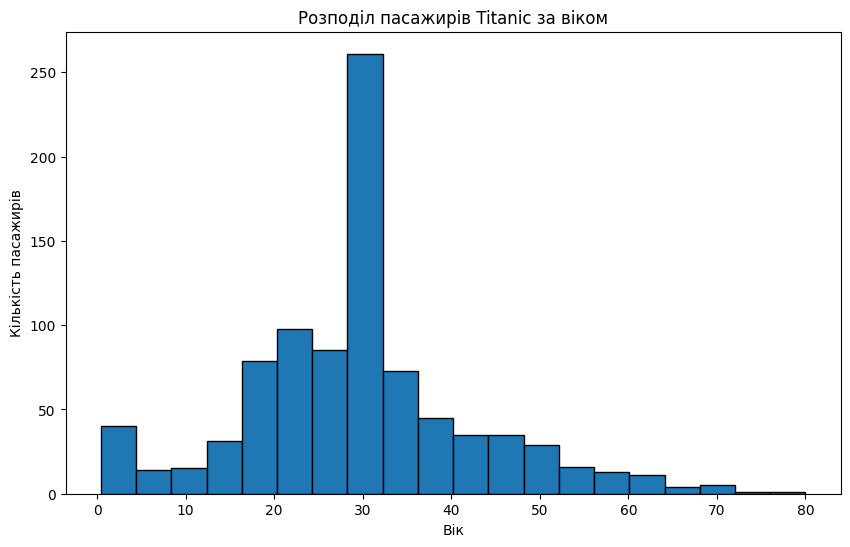

In [20]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Вік")
plt.ylabel("Кількість пасажирів")
plt.title("Розподіл пасажирів Titanic за віком")

plt.show()

14. Розрахувати частку кожної групи пасажирів

In [21]:
class_counts = df["Pclass"].value_counts().sort_index()

class_share = (
    class_counts / len(df)
) * 100

result = pd.DataFrame({
    "Кількість пасажирів": class_counts,
    "Частка (%)": class_share.round(2)
})

print("Частка пасажирів за класами:")
display(result)

Частка пасажирів за класами:


,Кількість пасажирів,Частка (%)
Pclass,,
1,216,24.24
2,184,20.65
3,491,55.11


In [22]:
sex_counts = df["Sex"].value_counts()

sex_share = (
    sex_counts / len(df)
) * 100

result = pd.DataFrame({
    "Кількість": sex_counts,
    "Частка (%)": sex_share.round(2)
})

print("Частка пасажирів за статтю:")
display(result)

Частка пасажирів за статтю:


,Кількість,Частка (%)
Sex,,
male,577,64.76
female,314,35.24


15. Візуалізувати зміни показників та проаналізувати залежність

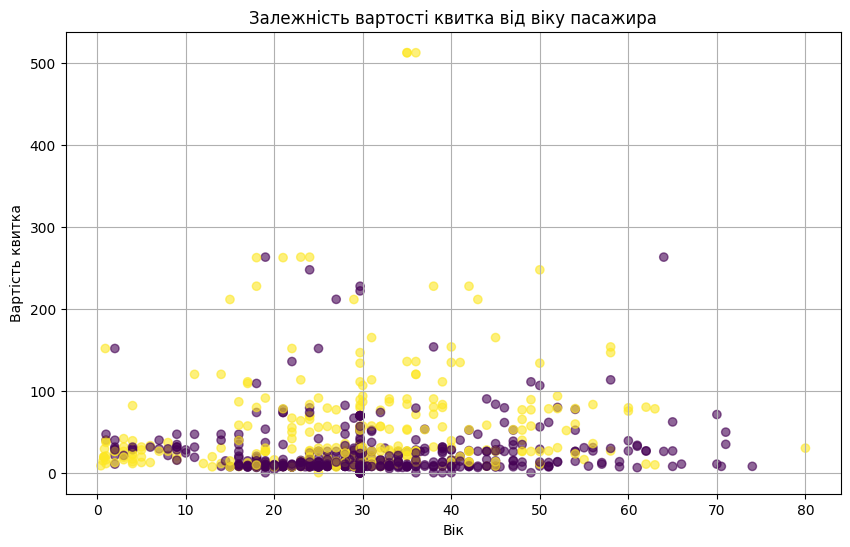

Коефіцієнт кореляції між віком та вартістю квитка: 0.0916


In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Age"],
    df["Fare"],
    c=df["Survived"],
    alpha=0.6
)

plt.xlabel("Вік")
plt.ylabel("Вартість квитка")
plt.title("Залежність вартості квитка від віку пасажира")

plt.grid(True)

plt.show()

correlation = df["Age"].corr(df["Fare"])

print(
    f"Коефіцієнт кореляції між віком "
    f"та вартістю квитка: {correlation:.4f}"
)

ЧАСТИНА 2. AMAZON BESTSELLERS

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

books = pd.read_csv("bestsellers with categories.csv")

print("Датасет Amazon успішно завантажено!")

Saving bestsellers with categories.csv to bestsellers with categories (1).csv
Датасет Amazon успішно завантажено!


1. Вивести перші 5 рядків

In [25]:
print("Перші 5 рядків датасета Amazon:")
display(books.head())

Перші 5 рядків датасета Amazon:


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


2. Визначити розмір датасета

In [26]:
print("Розмір датасета:", books.shape)
print("Кількість рядків:", books.shape[0])
print("Кількість стовпців:", books.shape[1])

Розмір датасета: (550, 7)
Кількість рядків: 550
Кількість стовпців: 7


3. Визначити оптимальну кількість стовпців

In [27]:
print("Стовпці датасета:")
print(books.columns.tolist())

Стовпці датасета:
['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre']


In [28]:
# Видалення технічного стовпця, якщо він присутній
if "Unnamed: 0" in books.columns:
    books = books.drop(columns=["Unnamed: 0"])

print("Розмір після видалення зайвого стовпця:", books.shape)

Розмір після видалення зайвого стовпця: (550, 7)


4. Перевірити та обробити пропущені значення

In [29]:
print("Кількість пропущених значень:")
print(books.isnull().sum())

Кількість пропущених значень:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64


In [30]:
numeric_columns = books.select_dtypes(include=np.number).columns

for column in numeric_columns:
    books[column] = books[column].fillna(
        books[column].mean()
    )

In [31]:
categorical_columns = books.select_dtypes(include="object").columns

for column in categorical_columns:
    if books[column].isnull().sum() > 0:
        books[column] = books[column].fillna(
            books[column].mode()[0]
        )

print("\nПропуски після обробки:")
print(books.isnull().sum())


Пропуски після обробки:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64


5. Ще раз вивести датасет

In [32]:
print("Датасет після обробки:")
display(books)

Датасет після обробки:


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


6. Перевірити наявність дублікатів

In [33]:
duplicates = books.duplicated().sum()

print("Кількість дублікатів:", duplicates)

Кількість дублікатів: 0


In [34]:
books = books.drop_duplicates()

print(
    "Розмір датасету після видалення дублікатів:",
    books.shape
)

Розмір датасету після видалення дублікатів: (550, 7)


7. Вивести описову статистику

In [35]:
print("Описова статистика:")
display(books.describe())

Описова статистика:


,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


8. Визначити відхилення середнього рейтингу за жанрами

In [36]:
average_rating = books.groupby("Genre")["User Rating"].mean()

overall_average = books["User Rating"].mean()

rating_difference = average_rating - overall_average

result = pd.DataFrame({
    "Середній рейтинг": average_rating,
    "Відхилення від загального середнього":
        rating_difference
})

print("Відхилення середнього рейтингу за жанрами:")

display(
    result.sort_values(
        "Відхилення від загального середнього",
        ascending=False
    )
)

print("\nЖанр із найбільшим позитивним відхиленням:")
print(rating_difference.idxmax())

print("\nЖанр із найбільшим негативним відхиленням:")
print(rating_difference.idxmin())

Відхилення середнього рейтингу за жанрами:


,Середній рейтинг,Відхилення від загального середнього
Genre,,
Fiction,4.648333,0.029970
Non Fiction,4.595161,-0.023202



Жанр із найбільшим позитивним відхиленням:
Fiction

Жанр із найбільшим негативним відхиленням:
Non Fiction


9. Обчислити кореляцію між числовими показниками

In [37]:
numeric_df = books.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("Кореляційна матриця:")
display(correlation_matrix)

Кореляційна матриця:


,User Rating,Reviews,Price,Year
User Rating,1.000000,-0.001729,-0.133086,0.242383
Reviews,-0.001729,1.000000,-0.109182,0.263560
Price,-0.133086,-0.109182,1.000000,-0.153979
Year,0.242383,0.263560,-0.153979,1.000000


In [38]:
corr_pairs = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=abs,
    ascending=False
)

print("Найсильніші кореляції:")
display(corr_pairs)

Найсильніші кореляції:


,,0
Reviews,Year,0.263560
User Rating,Year,0.242383
Price,Year,-0.153979
User Rating,Price,-0.133086
Reviews,Price,-0.109182
User Rating,Reviews,-0.001729


10. Обчислити середнє значення за стовпцями

In [39]:
mean_values = books.select_dtypes(
    include=np.number
).mean()

print("Середні значення за числовими стовпцями:")

display(
    mean_values.round(2)
)

Середні значення за числовими стовпцями:


,0
User Rating,4.62
Reviews,11953.28
Price,13.10
Year,2014.00


11. Обчислити стандартне відхилення

In [40]:
std_values = books.select_dtypes(
    include=np.number
).std()

print("Стандартне відхилення:")

display(
    std_values.sort_values(
        ascending=False
    ).round(2)
)

max_std_column = std_values.idxmax()
max_std_value = std_values.max()

print(
    f"\nНайвище стандартне відхилення має "
    f"'{max_std_column}': {max_std_value:.2f}"
)

Стандартне відхилення:


,0
Reviews,11731.13
Price,10.84
Year,3.17
User Rating,0.23



Найвище стандартне відхилення має 'Reviews': 11731.13


12. Знайти книги з найвищим та найнижчим рейтингом

In [41]:
max_index = books["User Rating"].idxmax()
max_book = books.loc[max_index]

min_index = books["User Rating"].idxmin()
min_book = books.loc[min_index]

print("Книга з найвищим рейтингом:")
print("Назва:", max_book["Name"])
print("Автор:", max_book["Author"])
print("Рейтинг:", max_book["User Rating"])

print("\nКнига з найнижчим рейтингом:")
print("Назва:", min_book["Name"])
print("Автор:", min_book["Author"])
print("Рейтинг:", min_book["User Rating"])

Книга з найвищим рейтингом:
Назва: Brown Bear, Brown Bear, What Do You See?
Автор: Bill Martin Jr.
Рейтинг: 4.9

Книга з найнижчим рейтингом:
Назва: The Casual Vacancy
Автор: J.K. Rowling
Рейтинг: 3.3


In [42]:
max_rating = books["User Rating"].max()
min_rating = books["User Rating"].min()

print("Книги з максимальним рейтингом:")
display(
    books[
        books["User Rating"] == max_rating
    ][["Name", "Author", "User Rating"]]
)

print("Книги з мінімальним рейтингом:")
display(
    books[
        books["User Rating"] == min_rating
    ][["Name", "Author", "User Rating"]]
)

Книги з максимальним рейтингом:


,Name,Author,User Rating
40,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9
41,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9
81,Dog Man and Cat Kid: From the Creator of Capta...,Dav Pilkey,4.9
82,Dog Man: A Tale of Two Kitties: From the Creat...,Dav Pilkey,4.9
83,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9
84,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9
85,Dog Man: Fetch-22: From the Creator of Captain...,Dav Pilkey,4.9
86,Dog Man: For Whom the Ball Rolls: From the Cre...,Dav Pilkey,4.9
87,Dog Man: Lord of the Fleas: From the Creator o...,Dav Pilkey,4.9
146,"Goodnight, Goodnight Construction Site (Hardco...",Sherri Duskey Rinker,4.9


Книги з мінімальним рейтингом:


,Name,Author,User Rating
353,The Casual Vacancy,J.K. Rowling,3.3


13. Побудувати гістограму розподілу рейтингів

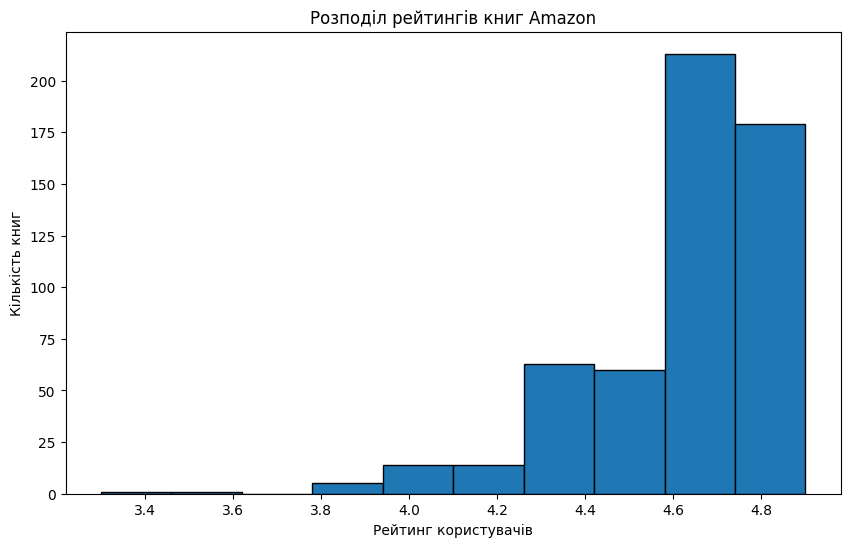

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(
    books["User Rating"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Рейтинг користувачів")
plt.ylabel("Кількість книг")
plt.title("Розподіл рейтингів книг Amazon")

plt.show()

14. Розрахувати частку кожного жанру

In [44]:
genre_counts = books["Genre"].value_counts()

genre_share = (
    genre_counts / len(books)
) * 100

result = pd.DataFrame({
    "Кількість книг": genre_counts,
    "Частка (%)": genre_share.round(2)
})

print("Частка кожного жанру:")

display(result)

Частка кожного жанру:


,Кількість книг,Частка (%)
Genre,,
Non Fiction,310,56.36
Fiction,240,43.64


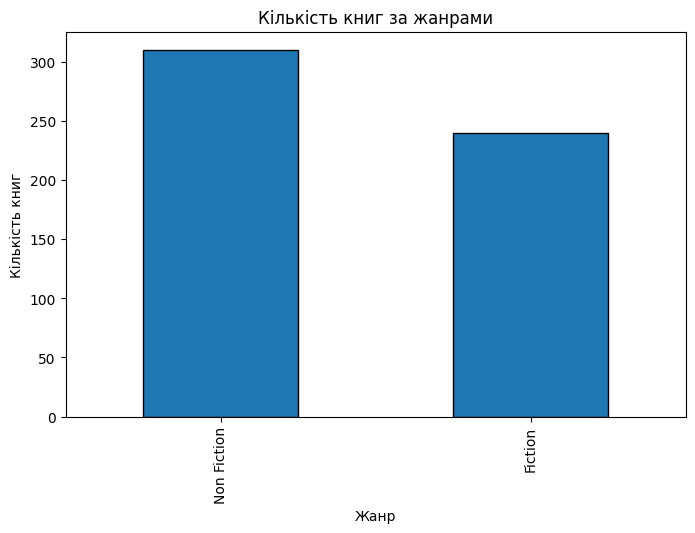

In [45]:
plt.figure(figsize=(8, 5))

genre_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Жанр")
plt.ylabel("Кількість книг")
plt.title("Кількість книг за жанрами")

plt.show()

15. Візуалізувати зміни показників за роками

In [46]:
year_rating = books.groupby("Year")["User Rating"].mean()

print("Середній рейтинг книг за роками:")
display(year_rating.round(2))

Середній рейтинг книг за роками:


,User Rating
Year,
2009,4.58
2010,4.56
2011,4.56
2012,4.53
2013,4.55
2014,4.62
2015,4.65
2016,4.68
2017,4.66


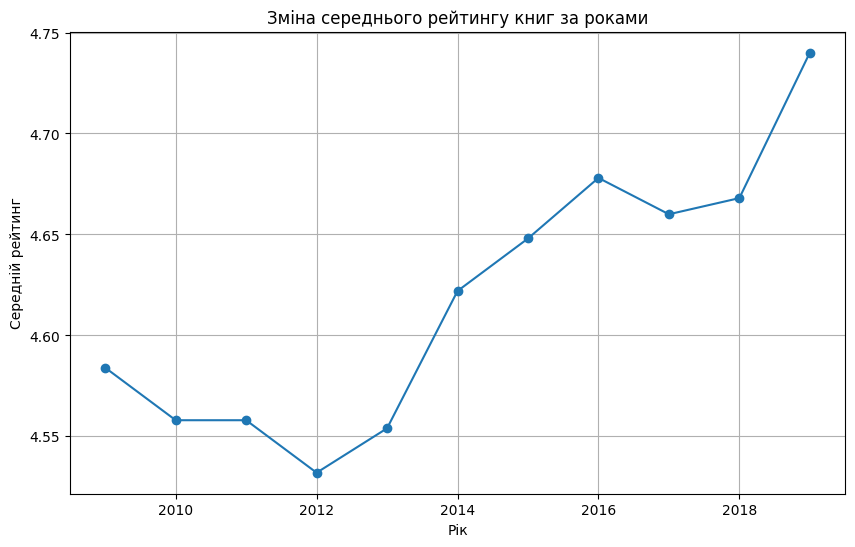

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_rating.index,
    year_rating.values,
    marker="o"
)

plt.xlabel("Рік")
plt.ylabel("Середній рейтинг")
plt.title("Зміна середнього рейтингу книг за роками")

plt.grid(True)

plt.show()

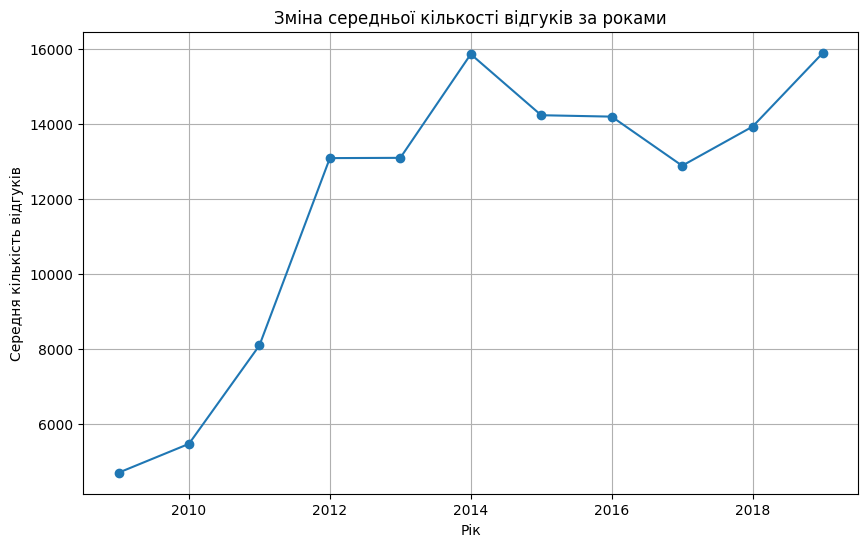

In [48]:
year_reviews = books.groupby("Year")["Reviews"].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    year_reviews.index,
    year_reviews.values,
    marker="o"
)

plt.xlabel("Рік")
plt.ylabel("Середня кількість відгуків")
plt.title("Зміна середньої кількості відгуків за роками")

plt.grid(True)

plt.show()

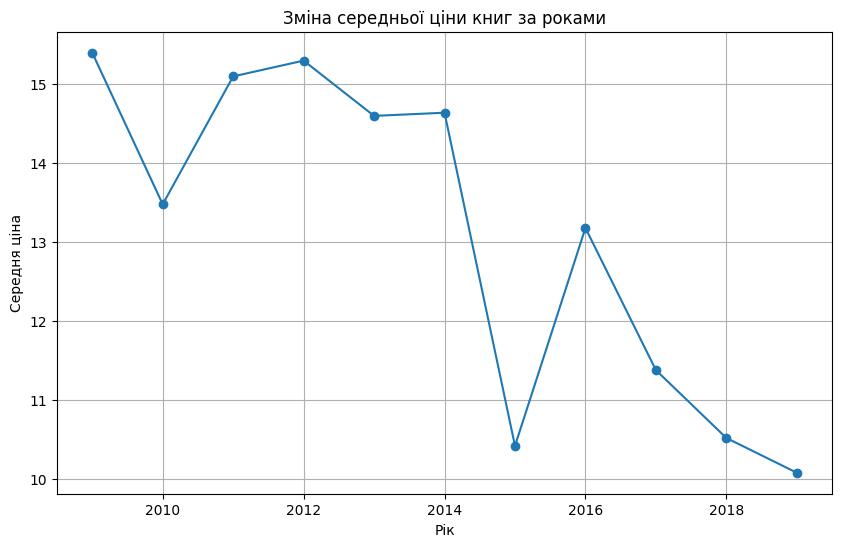

In [49]:
year_price = books.groupby("Year")["Price"].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    year_price.index,
    year_price.values,
    marker="o"
)

plt.xlabel("Рік")
plt.ylabel("Середня ціна")
plt.title("Зміна середньої ціни книг за роками")

plt.grid(True)

plt.show()